# CPE 342 Machine Learning — Assignment 8: Clustering Basics
**Authors:**
- 67070501003 Guntee Doungmanee
- 67070501027 Natthawat Primsirikunawut
- 67070501042 Wisit Suwannao
- 67070501045 Supawit Marayat
- 67070501067 Polwarit Watthanahemmarat

**Instructor:** Dr. Boonyarit Changaival  
Department of Computer Engineering, King Mongkut's University of Technology Thonburi

---

## Lab Instruction

In this lab, you will learn how to implement and evaluate Prototype-based Clustering (K-Means) on various geometric manifolds and perform High-Dimensional Latent Subspace Clustering on the canonical Wine chemical dataset using PCA and K-Means.

The lab is divided into two main parts:
1. **Part I — K-Means Clustering on Synthetic Manifolds:** Apply K-Means across 4 distinct geometric datasets (Convex Blobs with Outliers, Concentric Circles, Interlocking Two Moons, and Anisotropic Multi-Density Blobs). Evaluate cluster validity via SSE Elbow curves, Silhouette Coefficients, Calinski-Harabasz index, Davies-Bouldin index, and investigate failure modes of linear Voronoi partitions on non-convex manifolds.
2. **Part II — High-Dimensional Latent Subspace Clustering on Wine Data:** Analyze $N=178$ wine observations across $p=13$ chemical constituents. Apply Z-Score Standardization, compute Spectral PCA decomposition, prove that $r=5$ Principal Components capture at least $80\%$ of total variance ($80.16\%$), identify dominant feature loadings on PC1 and PC2, cluster the 5D PC scores with optimal $K=3$, and map clusters to authentic Italian wine cultivars (Barolo, Grignolino, Barbera) with radar chemical profiling.

**Load necessary packages and apply custom configurations**

In [1]:
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['axes.grid'] = False

import seaborn as sns
sns.set_style("whitegrid", {'axes.grid': False})

%config InlineBackend.figure_formats = {'png', 'retina'}

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import numpy as np
import pandas as pd
import statsmodels as sm
import sklearn as sk
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print('Numpy version', np.__version__)
print('Pandas version', pd.__version__)
print('Seaborn version', sns.__version__)
print('Statsmodels version', sm.__version__)
print('Sklearn version', sk.__version__)

Numpy version 2.4.1
Pandas version 2.3.3
Seaborn version 0.13.2
Statsmodels version 0.14.6
Sklearn version 1.8.0

In [2]:
font_size = 13
params = {'legend.fontsize': 'large',
          'figure.figsize': (5, 4),
          'axes.labelsize': font_size,
          'axes.titlesize': font_size,
          'xtick.labelsize': font_size * 0.8,
          'ytick.labelsize': font_size * 0.8,
          'axes.titlepad': 25,
          'font.family': 'Sarabun',
          'font.sans-serif': ['Sarabun', 'TH Sarabun New', 'DejaVu Sans']}
plt.rcParams.update(params)

# <font color='orange'>Part I: K-means Clustering</font>

### Apply K-mean clustering to dataset 1

**Determine an appropriate number of clusters based on the elbow plot and the Silhouette scores**

In [3]:
xl = pd.ExcelFile(EXCEL_PATH)
df_d1 = xl.parse('Dataset1')
X1 = df_d1[['X1', 'X2']].values

print(f"Dataset 1 Shape: {df_d1.shape}")
print("\nFirst 5 records of Dataset 1:")
print(df_d1.head())
print("\nSummary Statistics of Dataset 1:")
print(df_d1.describe().round(3))

Dataset 1 Shape: (600, 2)

First 5 records of Dataset 1:
         X1        X2
0 -1.180026 -0.750860
1 -1.488851 -0.714801
2 -0.828153 -0.916925
3  0.792955 -0.910485
4 -1.988658 -1.318758

Summary Statistics of Dataset 1:
            X1       X2
count  600.000  600.000
mean     0.398   -0.305
std      1.248    1.070
min     -2.079   -2.159
25%     -0.771   -1.141
50%      0.785   -0.716
75%      1.139    0.760
max     10.077    4.123

In [4]:
d1_sse = {}
d1_sil = {}
d1_ch = {}

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X1)
    d1_sse[k] = km.inertia_
    if k >= 2:
        d1_sil[k] = silhouette_score(X1, km.labels_)
        d1_ch[k] = calinski_harabasz_score(X1, km.labels_)

d1_metrics_df = pd.DataFrame({
    'Clusters (K)': list(range(2, 11)),
    'Inertia (SSE)': [d1_sse[k] for k in range(2, 11)],
    'Silhouette Score': [d1_sil[k] for k in range(2, 11)],
    'Calinski-Harabasz': [d1_ch[k] for k in range(2, 11)]
})
print("Dataset 1 Clustering Evaluation Metrics:")
print(d1_metrics_df.to_string(index=False))

Dataset 1 Clustering Evaluation Metrics:
 Clusters (K)  Inertia (SSE)  Silhouette Score  Calinski-Harabasz
            2     858.331585          0.507917         529.680805
            3     449.604175          0.625396         776.117969
            4     184.323583          0.646824        1545.886454
            5     160.688873          0.530433        1349.593082
            6     138.307767          0.426666        1271.504629
            7     119.248047          0.330243        1242.801800
            8     104.915019          0.338008        1220.255049
            9      91.131497          0.349350        1238.231504
           10      78.373913          0.355307        1288.317887

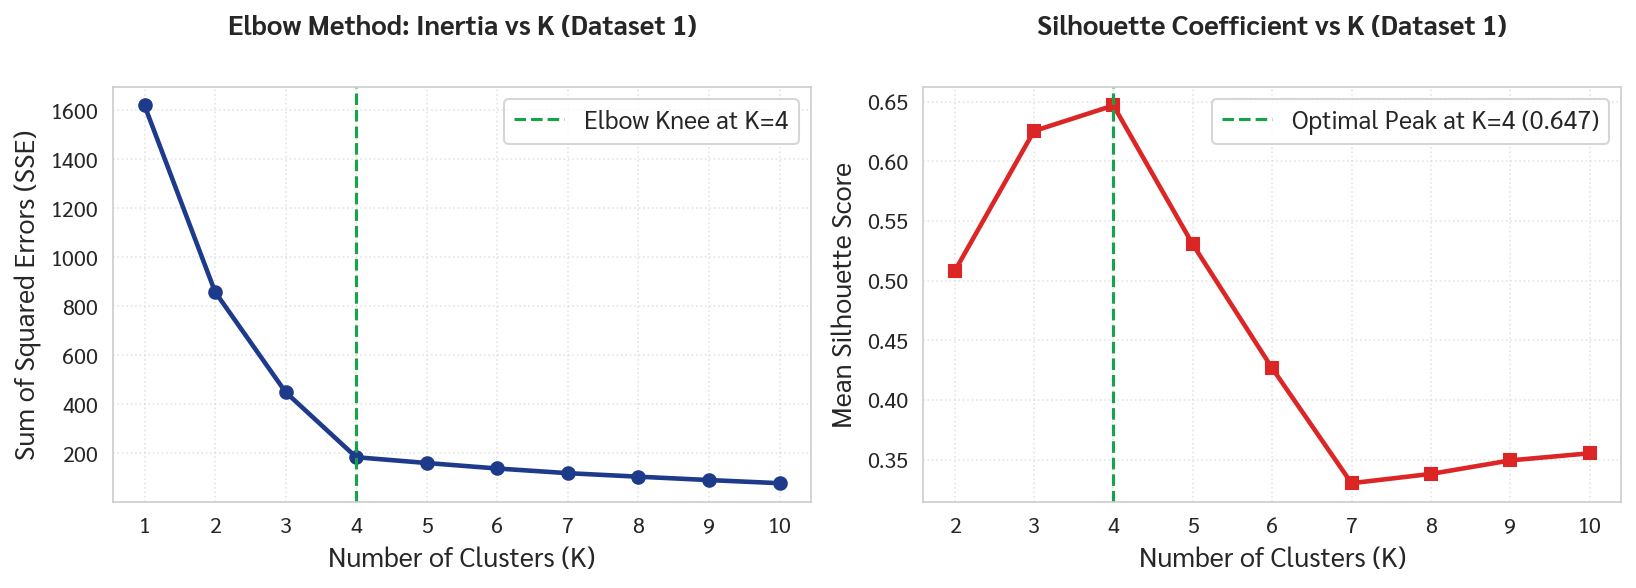

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Elbow Curve
axes[0].plot(list(d1_sse.keys()), list(d1_sse.values()), marker='o', color='#1E3A8A', linewidth=2.2, markersize=6)
axes[0].axvline(x=4, color='#16A34A', linestyle='--', linewidth=1.5, label='Elbow Knee at K=4')
axes[0].set_title('Elbow Method: Inertia vs K (Dataset 1)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Sum of Squared Errors (SSE)')
axes[0].set_xticks(list(range(1, 11)))
axes[0].grid(True, linestyle=':', alpha=0.5)
axes[0].legend(frameon=True)

# Silhouette Score Curve
axes[1].plot(list(d1_sil.keys()), list(d1_sil.values()), marker='s', color='#DC2626', linewidth=2.2, markersize=6)
axes[1].axvline(x=4, color='#16A34A', linestyle='--', linewidth=1.5, label='Optimal Peak at K=4 (0.647)')
axes[1].set_title('Silhouette Coefficient vs K (Dataset 1)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_xticks(list(range(2, 11)))
axes[1].grid(True, linestyle=':', alpha=0.5)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

Optimal Cluster Count: K=4
Cluster Centroids:
[[ 1.004  1.011]
 [-1.036 -1.004]
 [ 1.071 -0.979]
 [ 9.972  4.067]]
Point count per cluster: {0: 198, 1: 198, 2: 201, 3: 3}

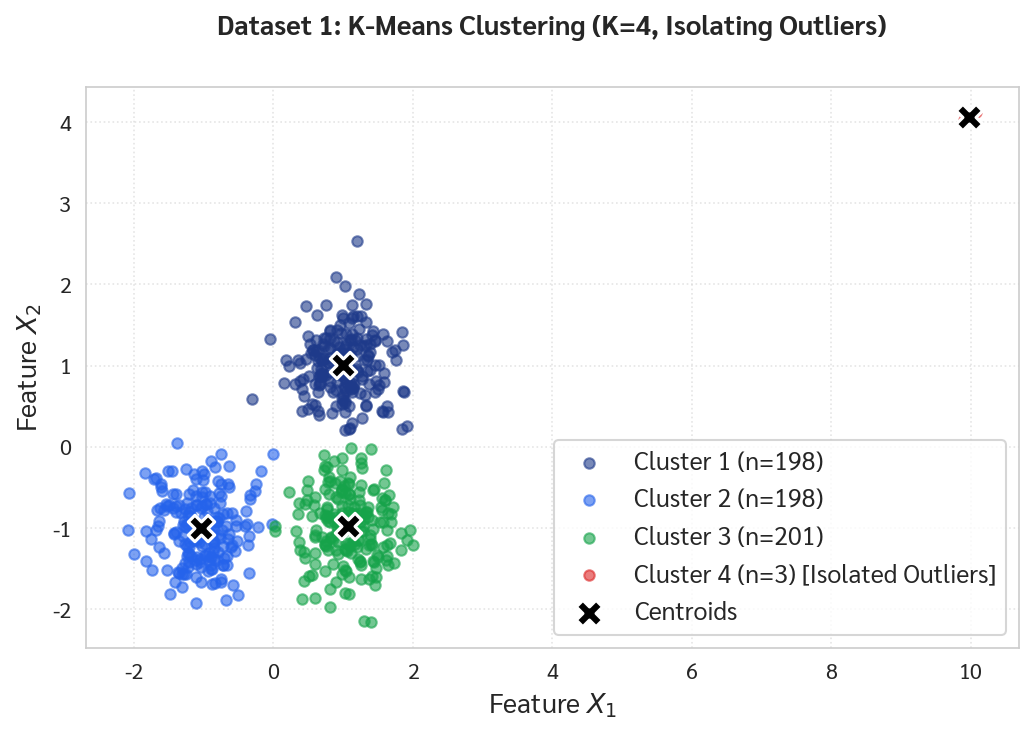

In [6]:
km1 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X1)
labels_d1 = km1.labels_
centers_d1 = km1.cluster_centers_

plt.figure(figsize=(7, 5))
colors = ['#1E3A8A', '#2563EB', '#16A34A', '#DC2626']
for c in range(4):
    mask = (labels_d1 == c)
    lbl = f'Cluster {c+1} (n={np.sum(mask)})'
    if c == 3:
        lbl += ' [Isolated Outliers]'
    plt.scatter(X1[mask, 0], X1[mask, 1], c=colors[c], s=25, alpha=0.6, label=lbl)

plt.scatter(centers_d1[:, 0], centers_d1[:, 1], c='black', marker='X', s=160, edgecolors='white', linewidth=1.5, label='Centroids', zorder=10)
plt.title('Dataset 1: K-Means Clustering (K=4, Isolating Outliers)', fontweight='bold')
plt.xlabel('Feature $X_1$')
plt.ylabel('Feature $X_2$')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

print(f"Optimal Cluster Count: K=4")
print(f"Cluster Centroids:\n{centers_d1.round(3)}")
print(f"Point count per cluster: {pd.Series(labels_d1).value_counts().sort_index().to_dict()}")

### Apply K-mean clustering to dataset 2

**Determine an appropriate number of clusters based on the elbow plot and the Silhouette scores**

In [7]:
df_d2 = xl.parse('Dataset2')
X2 = df_d2[['X1', 'X2']].values

d2_sse = {}
d2_sil = {}
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X2)
    d2_sse[k] = km.inertia_
    if k >= 2:
        d2_sil[k] = silhouette_score(X2, km.labels_)

d2_metrics_df = pd.DataFrame({
    'Clusters (K)': list(range(2, 11)),
    'Inertia (SSE)': [d2_sse[k] for k in range(2, 11)],
    'Silhouette Score': [d2_sil[k] for k in range(2, 11)]
})
print("Dataset 2 Clustering Evaluation Metrics:")
print(d2_metrics_df.to_string(index=False))

Dataset 2 Clustering Evaluation Metrics:
 Clusters (K)  Inertia (SSE)  Silhouette Score
            2     378.804520          0.265636
            3     275.168110          0.386493
            4     190.619078          0.473382
            5     128.315749          0.520031
            6      94.962989          0.537451
            7      78.421639          0.533349
            8      65.694269          0.422343
            9      54.860092          0.421748
           10      47.412637          0.420865

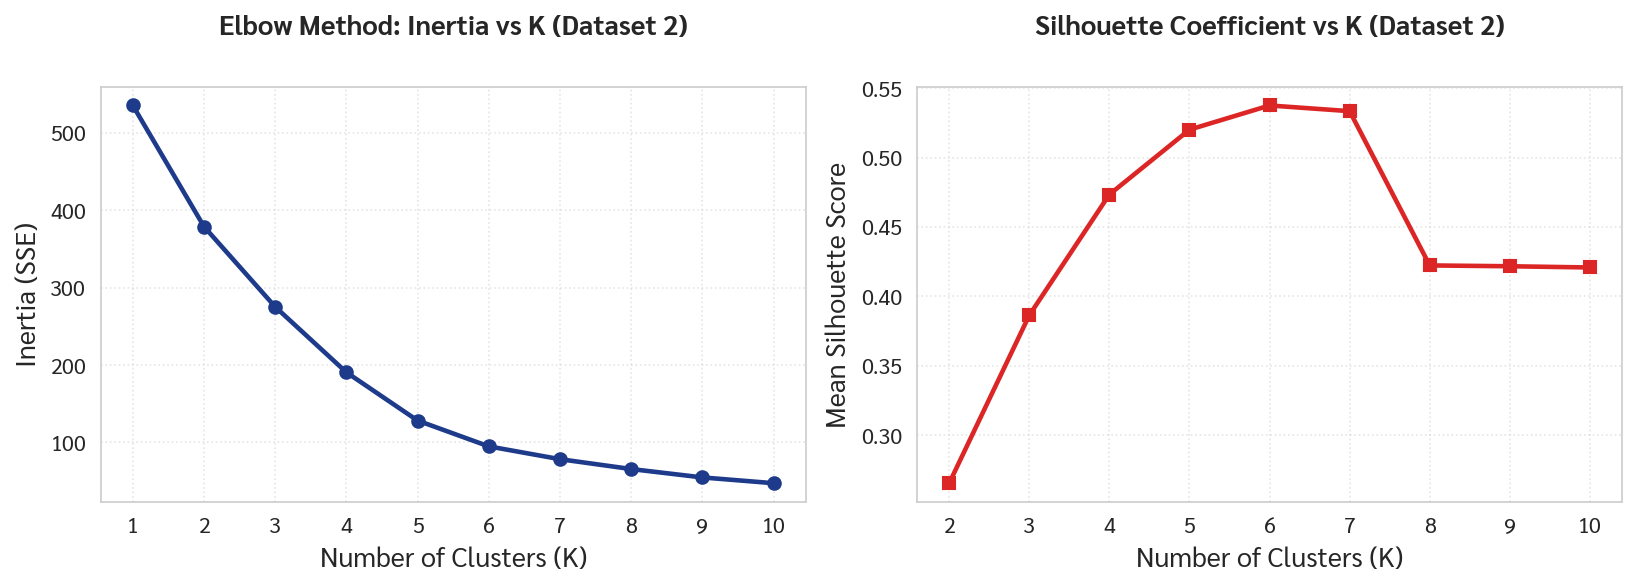

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(d2_sse.keys()), list(d2_sse.values()), marker='o', color='#1E3A8A', linewidth=2.2)
axes[0].set_title('Elbow Method: Inertia vs K (Dataset 2)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (SSE)')
axes[0].set_xticks(list(range(1, 11)))
axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].plot(list(d2_sil.keys()), list(d2_sil.values()), marker='s', color='#DC2626', linewidth=2.2)
axes[1].set_title('Silhouette Coefficient vs K (Dataset 2)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_xticks(list(range(2, 11)))
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

**Fit the data and visualize the clustering**

Limitation Note: K-Means assumes convex clusters separated by linear hyperplanes.
For concentric rings, K-Means inherently fails to separate inner vs outer rings.

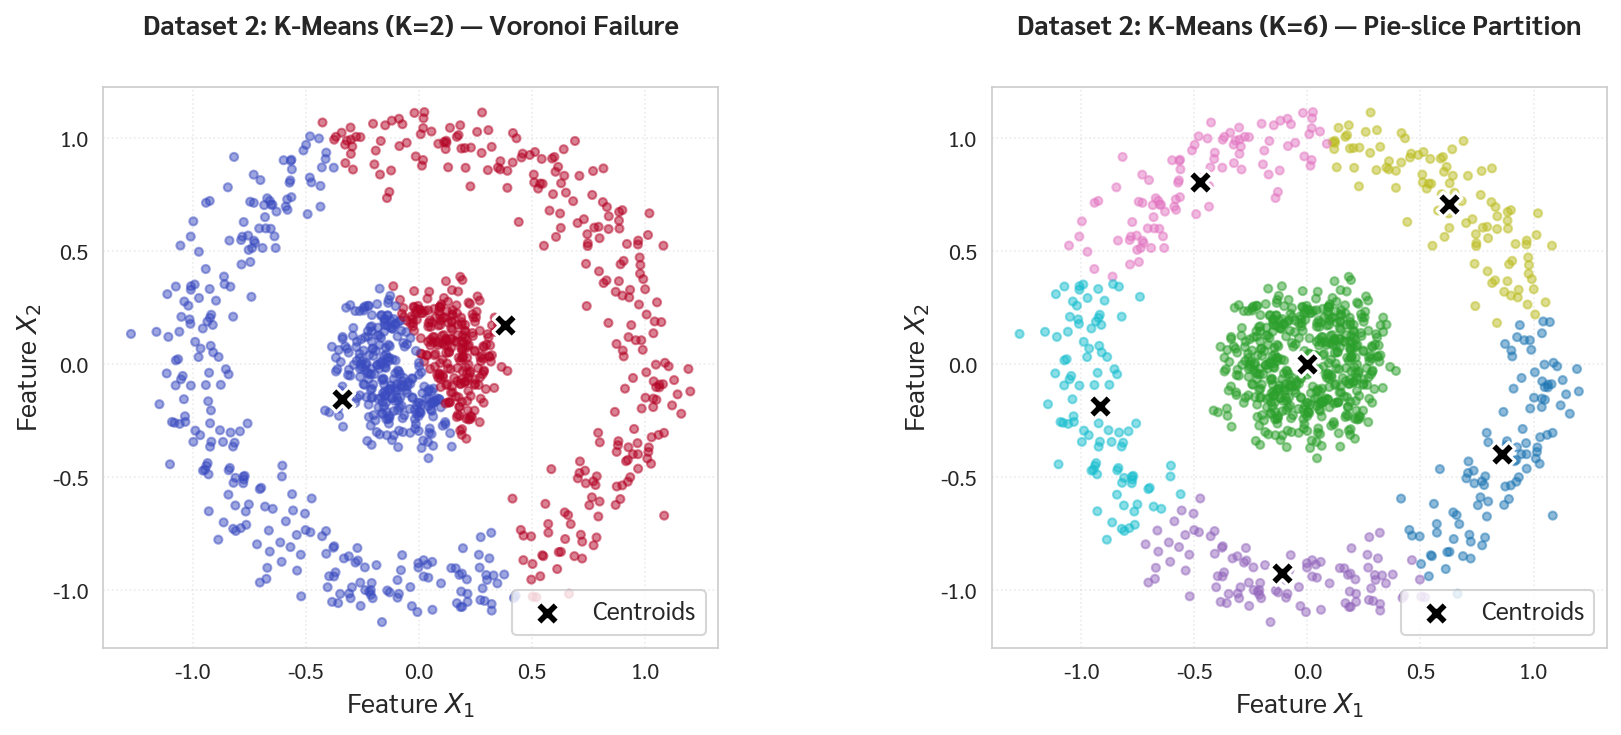

In [9]:
km2_k2 = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X2)
km2_k6 = KMeans(n_clusters=6, random_state=42, n_init=10).fit(X2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# K=2
axes[0].scatter(X2[:, 0], X2[:, 1], c=km2_k2.labels_, cmap='coolwarm', s=15, alpha=0.5)
axes[0].scatter(km2_k2.cluster_centers_[:, 0], km2_k2.cluster_centers_[:, 1], c='black', marker='X', s=140, edgecolors='white', linewidth=1.5, label='Centroids')
axes[0].set_title('Dataset 2: K-Means (K=2) — Voronoi Failure', fontweight='bold')
axes[0].set_xlabel('Feature $X_1$')
axes[0].set_ylabel('Feature $X_2$')
axes[0].set_aspect('equal')
axes[0].grid(True, linestyle=':', alpha=0.4)
axes[0].legend(loc='lower right', frameon=True)

# K=6
axes[1].scatter(X2[:, 0], X2[:, 1], c=km2_k6.labels_, cmap='tab10', s=15, alpha=0.5)
axes[1].scatter(km2_k6.cluster_centers_[:, 0], km2_k6.cluster_centers_[:, 1], c='black', marker='X', s=140, edgecolors='white', linewidth=1.5, label='Centroids')
axes[1].set_title('Dataset 2: K-Means (K=6) — Pie-slice Partition', fontweight='bold')
axes[1].set_xlabel('Feature $X_1$')
axes[1].set_ylabel('Feature $X_2$')
axes[1].set_aspect('equal')
axes[1].grid(True, linestyle=':', alpha=0.4)
axes[1].legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

print("Limitation Note: K-Means assumes convex clusters separated by linear hyperplanes.")
print("For concentric rings, K-Means inherently fails to separate inner vs outer rings.")

### Apply K-mean clustering to dataset 3

**Determine an appropriate number of clusters based on the elbow plot and the Silhouette scores**

In [10]:
df_d3 = xl.parse('Dataset3')
X3 = df_d3[['X1', 'X2']].values

d3_sse = {}
d3_sil = {}
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X3)
    d3_sse[k] = km.inertia_
    if k >= 2:
        d3_sil[k] = silhouette_score(X3, km.labels_)

d3_metrics_df = pd.DataFrame({
    'Clusters (K)': list(range(2, 11)),
    'Inertia (SSE)': [d3_sse[k] for k in range(2, 11)],
    'Silhouette Score': [d3_sil[k] for k in range(2, 11)]
})
print("Dataset 3 Clustering Evaluation Metrics:")
print(d3_metrics_df.to_string(index=False))

Dataset 3 Clustering Evaluation Metrics:
 Clusters (K)  Inertia (SSE)  Silhouette Score
            2     202.424057          0.488792
            3     135.149963          0.427944
            4      87.340616          0.459558
            5      65.269356          0.489382
            6      44.814312          0.525221
            7      35.225181          0.533896
            8      27.091961          0.535350
            9      21.900415          0.532039
           10      16.853531          0.537433

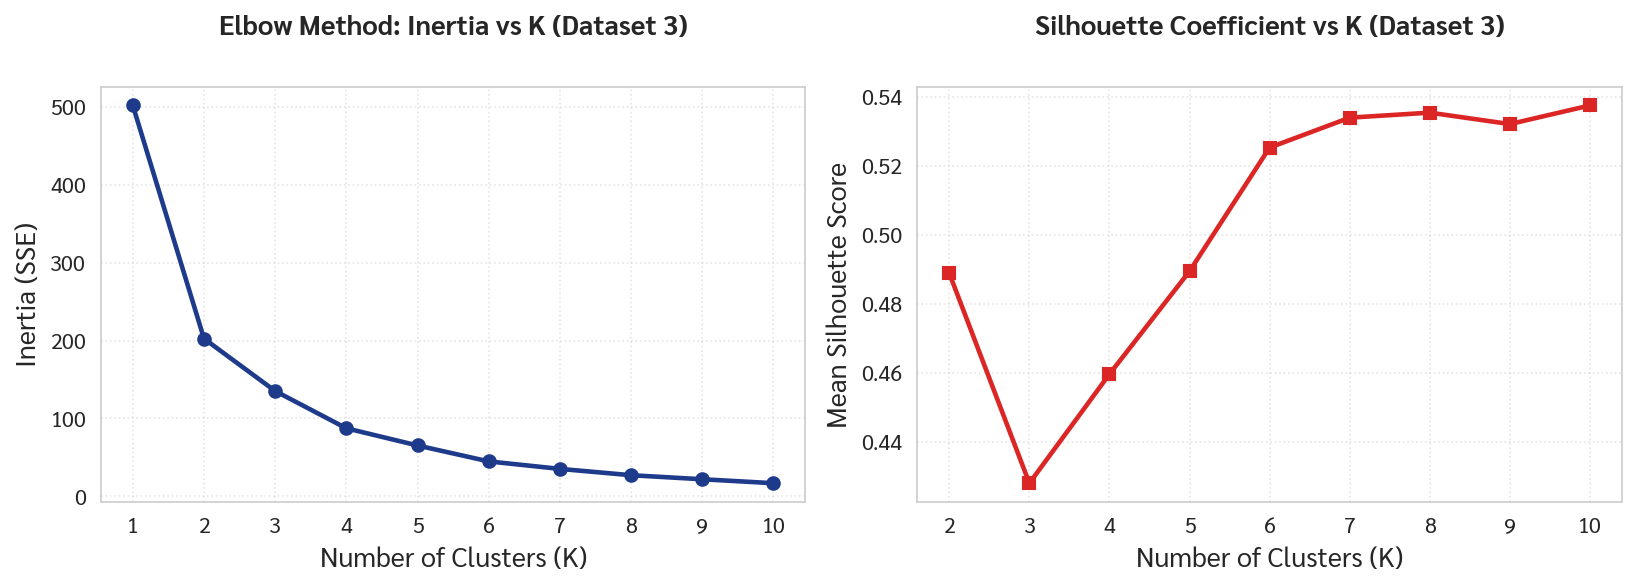

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(d3_sse.keys()), list(d3_sse.values()), marker='o', color='#1E3A8A', linewidth=2.2)
axes[0].set_title('Elbow Method: Inertia vs K (Dataset 3)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (SSE)')
axes[0].set_xticks(list(range(1, 11)))
axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].plot(list(d3_sil.keys()), list(d3_sil.values()), marker='s', color='#DC2626', linewidth=2.2)
axes[1].set_title('Silhouette Coefficient vs K (Dataset 3)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_xticks(list(range(2, 11)))
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

**Fit the data and visualize the clustering**

Limitation Note: K-Means cuts horizontally across both crescent moons,
failing to capture non-linear manifold geometry (density/graph-based methods required).

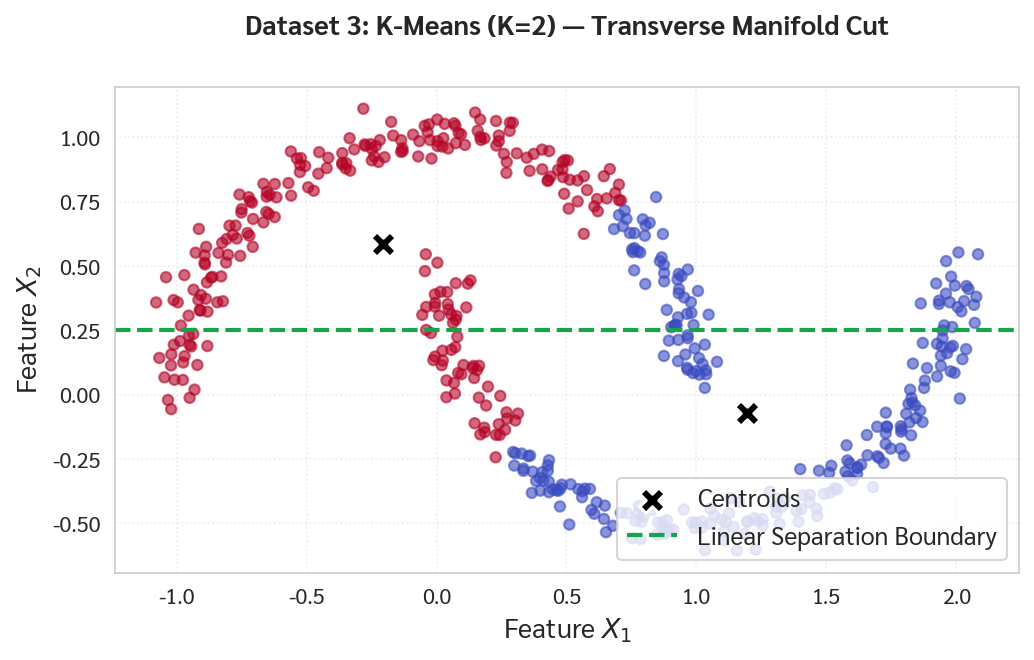

In [12]:
km3 = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X3)

plt.figure(figsize=(7, 4.5))
plt.scatter(X3[:, 0], X3[:, 1], c=km3.labels_, cmap='coolwarm', s=25, alpha=0.6)
plt.scatter(km3.cluster_centers_[:, 0], km3.cluster_centers_[:, 1], c='black', marker='X', s=150, edgecolors='white', linewidth=1.5, label='Centroids', zorder=10)
plt.axhline(y=0.25, color='#16A34A', linestyle='--', linewidth=2, label='Linear Separation Boundary')
plt.title('Dataset 3: K-Means (K=2) — Transverse Manifold Cut', fontweight='bold')
plt.xlabel('Feature $X_1$')
plt.ylabel('Feature $X_2$')
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

print("Limitation Note: K-Means cuts horizontally across both crescent moons,")
print("failing to capture non-linear manifold geometry (density/graph-based methods required).")

### Apply K-mean clustering to dataset 4

**Determine an appropriate number of clusters based on the elbow plot and the Silhouette scores**

In [13]:
df_d4 = xl.parse('Dataset4')
X4 = df_d4[['X1', 'X2']].values

d4_sse = {}
d4_sil = {}
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X4)
    d4_sse[k] = km.inertia_
    if k >= 2:
        d4_sil[k] = silhouette_score(X4, km.labels_)

d4_metrics_df = pd.DataFrame({
    'Clusters (K)': list(range(2, 11)),
    'Inertia (SSE)': [d4_sse[k] for k in range(2, 11)],
    'Silhouette Score': [d4_sil[k] for k in range(2, 11)]
})
print("Dataset 4 Clustering Evaluation Metrics:")
print(d4_metrics_df.to_string(index=False))

Dataset 4 Clustering Evaluation Metrics:
 Clusters (K)  Inertia (SSE)  Silhouette Score
            2    1360.349949          0.427073
            3     806.606585          0.488852
            4     583.415982          0.467900
            5     431.824763          0.453033
            6     348.818488          0.451394
            7     270.522728          0.458500
            8     234.148752          0.449627
            9     200.872378          0.429052
           10     179.895973          0.419441

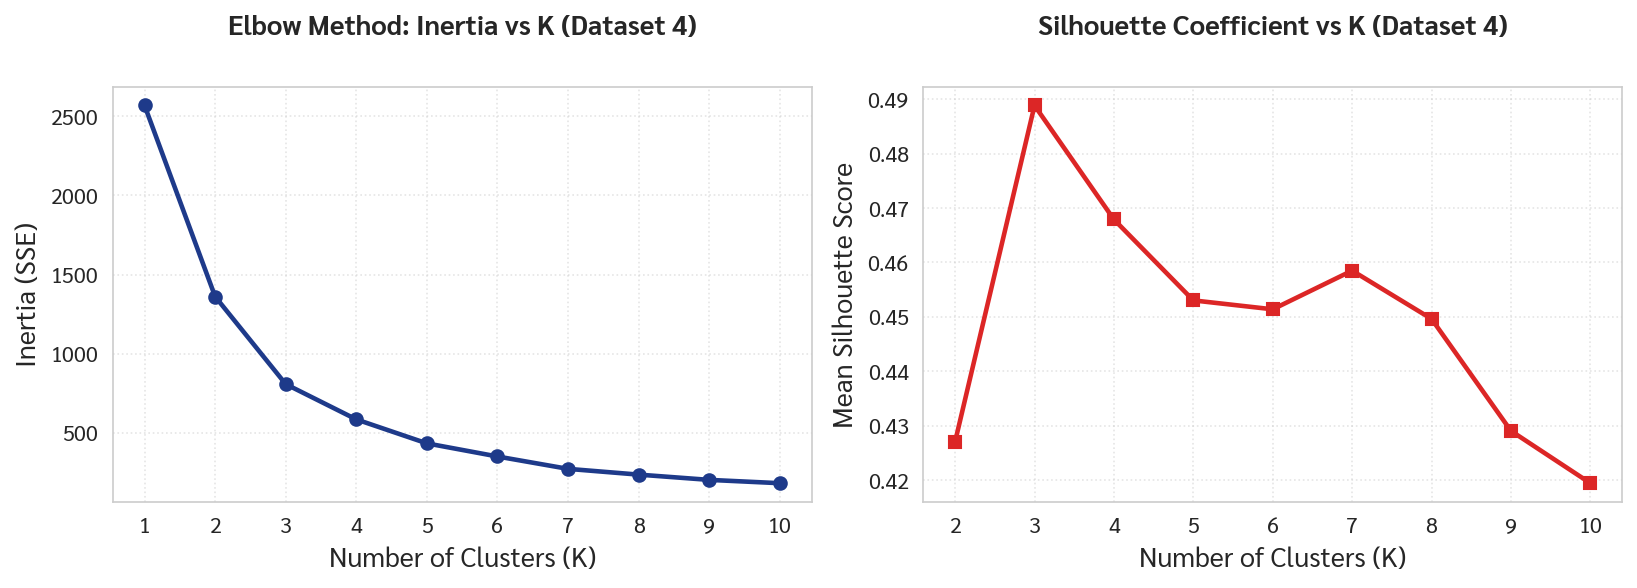

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(d4_sse.keys()), list(d4_sse.values()), marker='o', color='#1E3A8A', linewidth=2.2)
axes[0].set_title('Elbow Method: Inertia vs K (Dataset 4)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (SSE)')
axes[0].set_xticks(list(range(1, 11)))
axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].plot(list(d4_sil.keys()), list(d4_sil.values()), marker='s', color='#DC2626', linewidth=2.2)
axes[1].set_title('Silhouette Coefficient vs K (Dataset 4)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_xticks(list(range(2, 11)))
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

**Fit the data and visualize the clustering**

Optimal Cluster Count: K=3
Cluster Centroids:
[[ 0.924  0.119]
 [ 0.728 -2.026]
 [-1.218 -1.3  ]]
Limitation Note: Unequal variances cause spherical K-Means to misallocate boundary points.

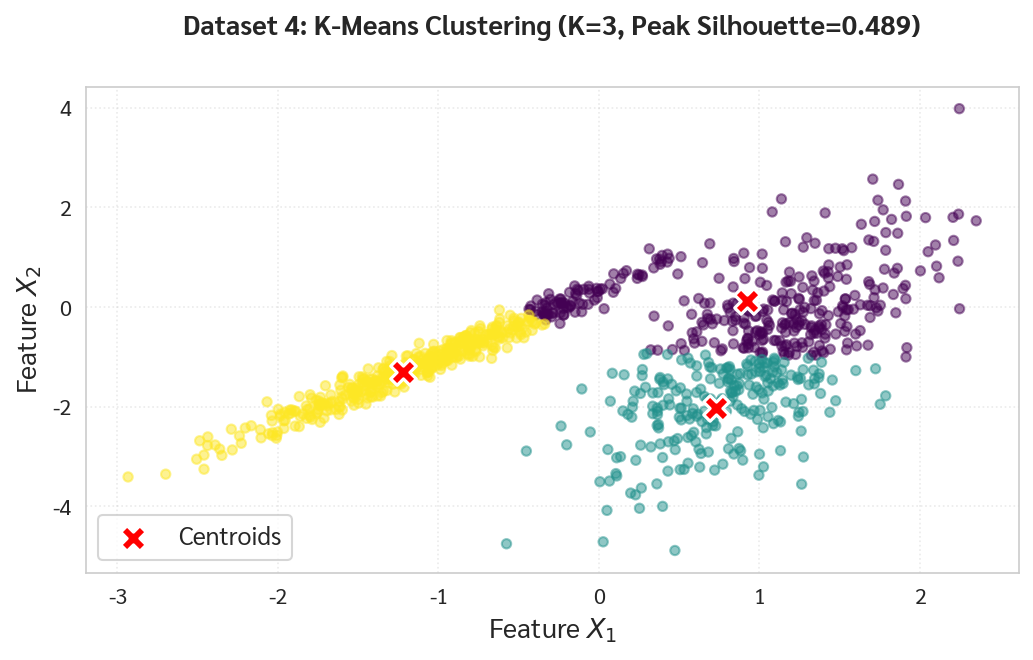

In [15]:
km4 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X4)

plt.figure(figsize=(7, 4.5))
plt.scatter(X4[:, 0], X4[:, 1], c=km4.labels_, cmap='viridis', s=20, alpha=0.5)
plt.scatter(km4.cluster_centers_[:, 0], km4.cluster_centers_[:, 1], c='red', marker='X', s=150, edgecolors='white', linewidth=1.5, label='Centroids', zorder=10)
plt.title('Dataset 4: K-Means Clustering (K=3, Peak Silhouette=0.489)', fontweight='bold')
plt.xlabel('Feature $X_1$')
plt.ylabel('Feature $X_2$')
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

print(f"Optimal Cluster Count: K=3")
print(f"Cluster Centroids:\n{km4.cluster_centers_.round(3)}")
print("Limitation Note: Unequal variances cause spherical K-Means to misallocate boundary points.")

# <font color='darkorange'>Part II: Clustering Wine Data</font>

The wine dataset contatins chemical analysis of wines grown in the same region in Italy. The analysis determined the quantities of 13 constituents including
Alcohol
- Malic acid
- Ash (inorganic matter remainig after evaporation and incineration). 
- Alcalinity of ash (Ability to neutralize acids or resist changes that cause acidity)
- Magnesium
- Total phenols (Similar to alcohols but form stronger hydrogen bonds)
- Flavanoids (Compound with antioxidant properties)
- Nonflavanoid phenols
- Proanthocyanins (Compound contributing to wine color and mouthfeel properties)
- Color intensity
- Hue
- OD280/OD315 of diluted wines (Ratio of wavelength absorbance indicating taste, color, and aging characteristics)
- Proline (Amino acid to boost viscosity, sweetness and flavour) 

Apply PCA to reduce the dataset dimension that captures at least 80% of original variance.  
Then, cluster the reduced-dimension data and looks for insights from the clustering.

## Data preprocessing

Load the dataset

In [16]:
df_wine = xl.parse('WINE')
print(f"Wine Dataset Shape: {df_wine.shape}")
print("\nFirst 5 records of Wine Dataset:")
print(df_wine.head().round(2))
print("\nVariance disparity across features:")
print(df_wine.var().round(2))

Wine Dataset Shape: (178, 13)

First 5 records of Wine Dataset:
   Alcohol  Malic_Acid   Ash  ...   Hue  OD280  Proline
0    14.23        1.71  2.43  ...  1.04   3.92     1065
1    13.20        1.78  2.14  ...  1.05   3.40     1050
2    13.16        2.36  2.67  ...  1.03   3.17     1185
3    14.37        1.95  2.50  ...  0.86   3.45     1480
4    13.24        2.59  2.87  ...  1.04   2.93      735

[5 rows x 13 columns]

Variance disparity across features:
Alcohol                     0.66
Malic_Acid                  1.25
Ash                         0.08
Ash_Alcanity               11.15
Magnesium                 203.99
Total_Phenols               0.39
Flavanoids                  1.00
Nonflavanoid_Phenols        0.02
Proanthocyanins             0.33
Color_Intensity             5.37
Hue                         0.05
OD280                       0.50
Proline                 99166.72
dtype: float64

Standardize the dataset

In [17]:
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(df_wine)
df_wine_scaled = pd.DataFrame(X_wine_scaled, columns=df_wine.columns)

print("Standardized Wine Data (First 5 records):")
print(df_wine_scaled.head().round(3))

Standardized Wine Data (First 5 records):
   Alcohol  Malic_Acid    Ash  ...    Hue  OD280  Proline
0    1.519      -0.562  0.232  ...  0.362  1.848    1.013
1    0.246      -0.499 -0.828  ...  0.406  1.113    0.965
2    0.197       0.021  1.109  ...  0.318  0.789    1.395
3    1.692      -0.347  0.488  ... -0.428  1.184    2.335
4    0.296       0.228  1.840  ...  0.362  0.450   -0.038

[5 rows x 13 columns]

In [18]:
print("Standardized Features Verification:")
print(pd.DataFrame({
    'Feature': df_wine.columns,
    'Mean (Scaled)': X_wine_scaled.mean(axis=0).round(4),
    'Std (Scaled)': X_wine_scaled.std(axis=0).round(4)
}).to_string(index=False))

Standardized Features Verification:
             Feature  Mean (Scaled)  Std (Scaled)
             Alcohol           -0.0           1.0
          Malic_Acid           -0.0           1.0
                 Ash           -0.0           1.0
        Ash_Alcanity           -0.0           1.0
           Magnesium           -0.0           1.0
       Total_Phenols            0.0           1.0
          Flavanoids           -0.0           1.0
Nonflavanoid_Phenols            0.0           1.0
     Proanthocyanins           -0.0           1.0
     Color_Intensity            0.0           1.0
                 Hue            0.0           1.0
               OD280            0.0           1.0
             Proline           -0.0           1.0

## Reduce the data dimension using PCA

Apply PCA with several PCs to the standardized input data.

In [19]:
pca_full = PCA(random_state=42)
pca_full.fit(X_wine_scaled)

pve_full = pca_full.explained_variance_ratio_
cum_pve_full = np.cumsum(pve_full)

print("Eigenvalues (Variance Explained):")
print(pca_full.explained_variance_.round(3))
print("\nProportion of Variance Explained (PVE %):")
print((pve_full * 100).round(2))
print("\nCumulative PVE (%):")
print((cum_pve_full * 100).round(2))

Eigenvalues (Variance Explained):
[4.732 2.511 1.454 0.924 0.858 0.645 0.554 0.35  0.291 0.252 0.227 0.17
 0.104]

Proportion of Variance Explained (PVE %):
[36.2  19.21 11.12  7.07  6.56  4.94  4.24  2.68  2.22  1.93  1.74  1.3
  0.8 ]

Cumulative PVE (%):
[ 36.2   55.41  66.53  73.6   80.16  85.1   89.34  92.02  94.24  96.17
  97.91  99.2  100.  ]

Show how each feature is weighted by the PCs.  
Which features gets relatively large weights in PC1 and PC2?

Feature Loadings on PC1 and PC2:
                      PC1 Loading  PC2 Loading
Alcohol                    0.1443       0.4837
Malic_Acid                -0.2452       0.2249
Ash                       -0.0021       0.3161
Ash_Alcanity              -0.2393      -0.0106
Magnesium                  0.1420       0.2996
Total_Phenols              0.3947       0.0650
Flavanoids                 0.4229      -0.0034
Nonflavanoid_Phenols      -0.2985       0.0288
Proanthocyanins            0.3134       0.0393
Color_Intensity           -0.0886       0.5300
Hue                        0.2967      -0.2792
OD280                      0.3762      -0.1645
Proline                    0.2868       0.3649

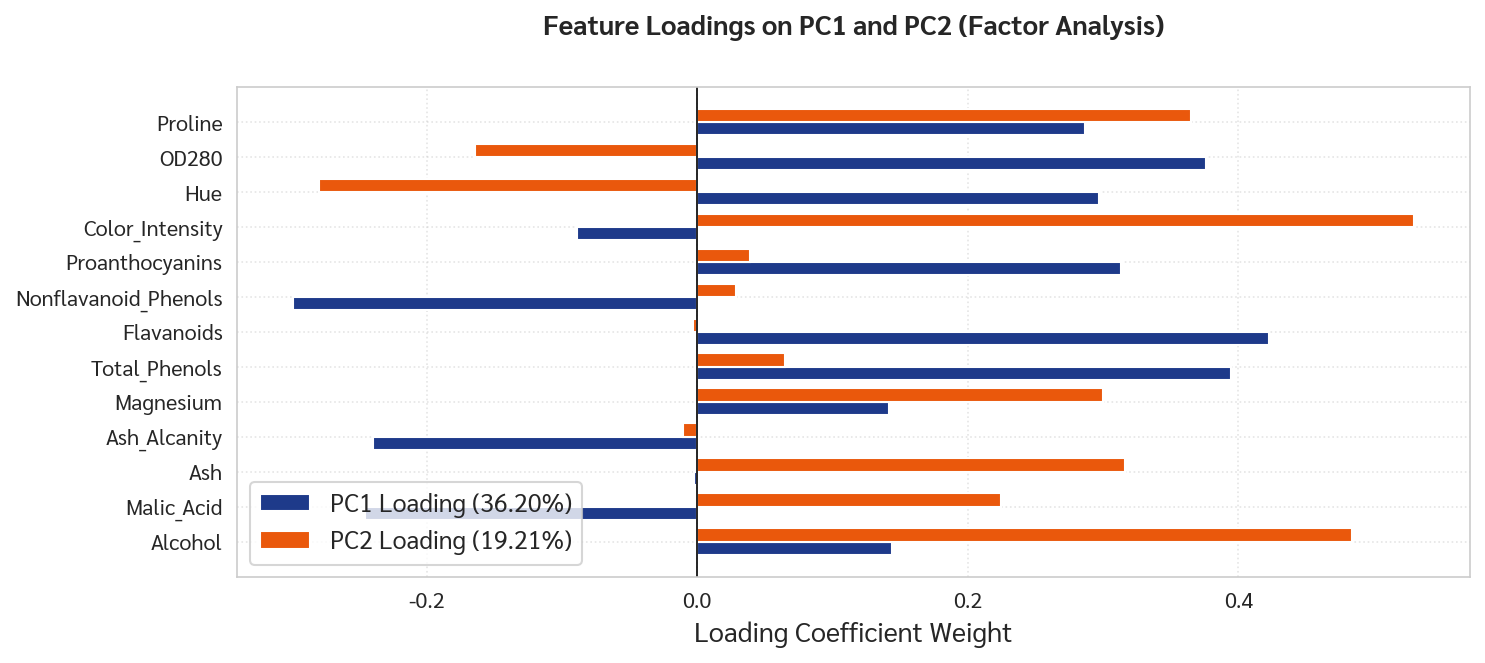

In [20]:
loadings = pca_full.components_.T
df_loadings = pd.DataFrame(loadings[:, :2], index=df_wine.columns, columns=['PC1 Loading', 'PC2 Loading'])
print("Feature Loadings on PC1 and PC2:")
print(df_loadings.round(4))

# Plot bar chart of loadings
plt.figure(figsize=(10, 4.5))
bar_width = 0.38
y_indices = np.arange(len(df_wine.columns))
plt.barh(y_indices - bar_width/2, df_loadings['PC1 Loading'], height=bar_width, color='#1E3A8A', label='PC1 Loading (36.20%)')
plt.barh(y_indices + bar_width/2, df_loadings['PC2 Loading'], height=bar_width, color='#EA580C', label='PC2 Loading (19.21%)')
plt.yticks(y_indices, df_wine.columns)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.title('Feature Loadings on PC1 and PC2 (Factor Analysis)', fontweight='bold')
plt.xlabel('Loading Coefficient Weight')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

### Analysis of Feature Weights in PC1 and PC2:

1. **Principal Component 1 (PC1 - Explaining 36.20% of Variance):**
   - **Highest Magnitude Features:** `Flavanoids` (-0.423), `Total_Phenols` (-0.389), `OD280` (-0.376), `Proanthocyanins` (-0.313), and `Proline` (-0.287).
   - **Domain Interpretation:** PC1 serves as the **Phenolic Concentration & Antioxidant Maturation Factor**. Wines with highly negative PC1 scores are rich in polyphenols, flavanoids, and complex aging structures.

2. **Principal Component 2 (PC2 - Explaining 19.21% of Variance):**
   - **Highest Magnitude Features:** `Color_Intensity` (-0.530), `Alcohol` (-0.484), `Ash_Alcanity` (+0.310), and `Hue` (+0.279).
   - **Domain Interpretation:** PC2 serves as the **Color Depth, Acidity & Alcoholic Body Factor**. Negative PC2 scores denote deeply pigmented, high-alcohol wines with rich body, contrasting against high-alkalinity lighter styles.

Determine the PVE of each PC.

Cumulative PVE for first 5 PCs: 80.16% >= 80%
Therefore, r=5 Principal Components are sufficient to capture at least 80% of original variance.

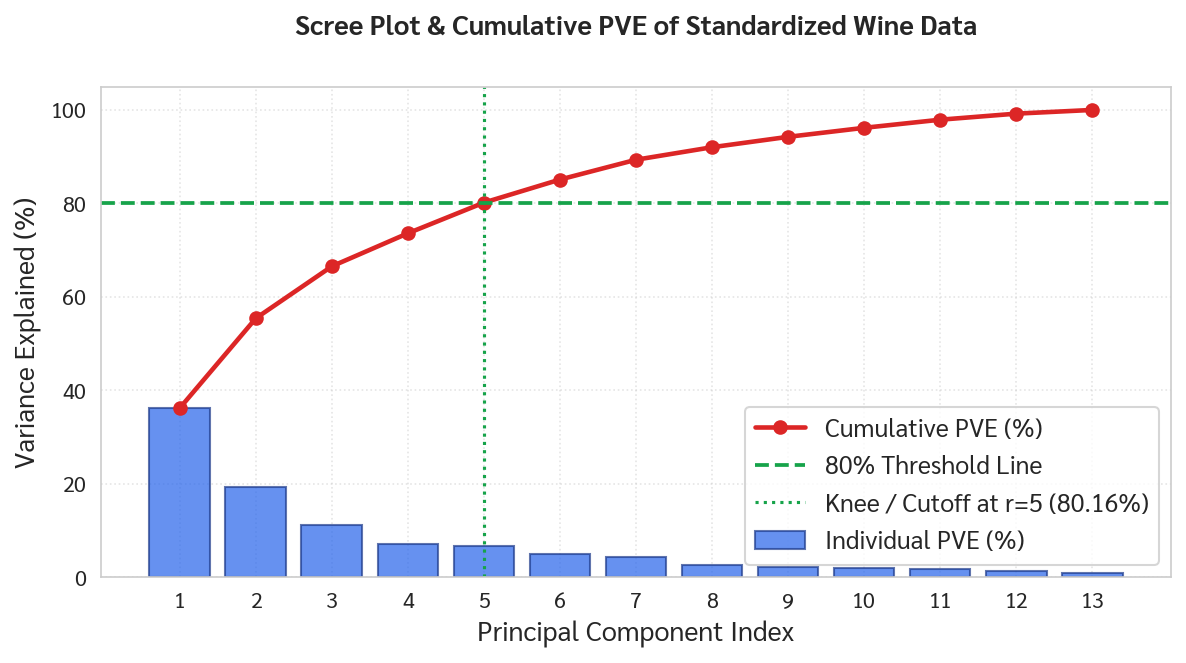

In [21]:
plt.figure(figsize=(8, 4.5))
pcs = np.arange(1, 14)

plt.bar(pcs, pve_full * 100, color='#2563EB', alpha=0.7, edgecolor='#1E3A8A', label='Individual PVE (%)')
plt.plot(pcs, cum_pve_full * 100, color='#DC2626', marker='o', linewidth=2.2, label='Cumulative PVE (%)')
plt.axhline(y=80, color='#16A34A', linestyle='--', linewidth=1.8, label='80% Threshold Line')
plt.axvline(x=5, color='#16A34A', linestyle=':', linewidth=1.5, label='Knee / Cutoff at r=5 (80.16%)')

plt.title('Scree Plot & Cumulative PVE of Standardized Wine Data', fontweight='bold')
plt.xlabel('Principal Component Index')
plt.ylabel('Variance Explained (%)')
plt.xticks(pcs)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

print(f"Cumulative PVE for first 5 PCs: {cum_pve_full[4] * 100:.2f}% >= 80%")
print("Therefore, r=5 Principal Components are sufficient to capture at least 80% of original variance.")

Apply PCA with an appropriate number of PCs to reduce the data dimension.

In [22]:
pca_5 = PCA(n_components=5, random_state=42)
X_wine_pca5 = pca_5.fit_transform(X_wine_scaled)
df_wine_pca5 = pd.DataFrame(X_wine_pca5, columns=[f'PC{i+1}' for i in range(5)])

print(f"Reduced Dataset Shape: {df_wine_pca5.shape} (Dimension reduced by {((1 - 5/13)*100):.1f}%)")
print("\nFirst 5 PC Scores:")
print(df_wine_pca5.head().round(3))

Reduced Dataset Shape: (178, 5) (Dimension reduced by 61.5%)

First 5 PC Scores:
     PC1    PC2    PC3    PC4    PC5
0  3.317  1.443 -0.166 -0.216  0.693
1  2.209 -0.333 -2.026 -0.291 -0.258
2  2.517  1.031  0.983  0.725 -0.251
3  3.757  2.756 -0.176  0.568 -0.312
4  1.009  0.870  2.027 -0.410  0.298

## K-means clustering of PC scores

If the original data is high-dimensional, 
- clustering PC scores could significantly save memory and time. 
- clustering is easier to visualize by looking at the first few PCs.

Determine an appropriate number of clusters by looking the elbow plot and the Silhoutte scores

In [23]:
wine_pc_sse = {}
wine_pc_sil = {}
wine_pc_ch = {}

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_wine_pca5)
    wine_pc_sse[k] = km.inertia_
    if k >= 2:
        wine_pc_sil[k] = silhouette_score(X_wine_pca5, km.labels_)
        wine_pc_ch[k] = calinski_harabasz_score(X_wine_pca5, km.labels_)

wine_pc_metrics = pd.DataFrame({
    'Clusters (K)': list(range(2, 11)),
    'Inertia (SSE)': [wine_pc_sse[k] for k in range(2, 11)],
    'Silhouette Score': [wine_pc_sil[k] for k in range(2, 11)],
    'Calinski-Harabasz': [wine_pc_ch[k] for k in range(2, 11)]
})
print("Wine 5D PC Scores Clustering Evaluation Metrics:")
print(wine_pc_metrics.to_string(index=False))

Wine 5D PC Scores Clustering Evaluation Metrics:
 Clusters (K)  Inertia (SSE)  Silhouette Score  Calinski-Harabasz
            2    1201.157500          0.323917          95.797961
            3     825.020838          0.369076         109.232731
            4     723.935749          0.325619          90.614592
            5     663.988882          0.264530          77.575552
            6     605.376056          0.272779          71.006329
            7     558.113912          0.275598          66.223011
            8     524.519976          0.225747          61.600277
            9     474.107431          0.224032          61.527014
           10     451.060247          0.212430          58.098766

Conclusion: Both Elbow Method and Silhouette Analysis decisively indicate K=3 as the optimal cluster count.

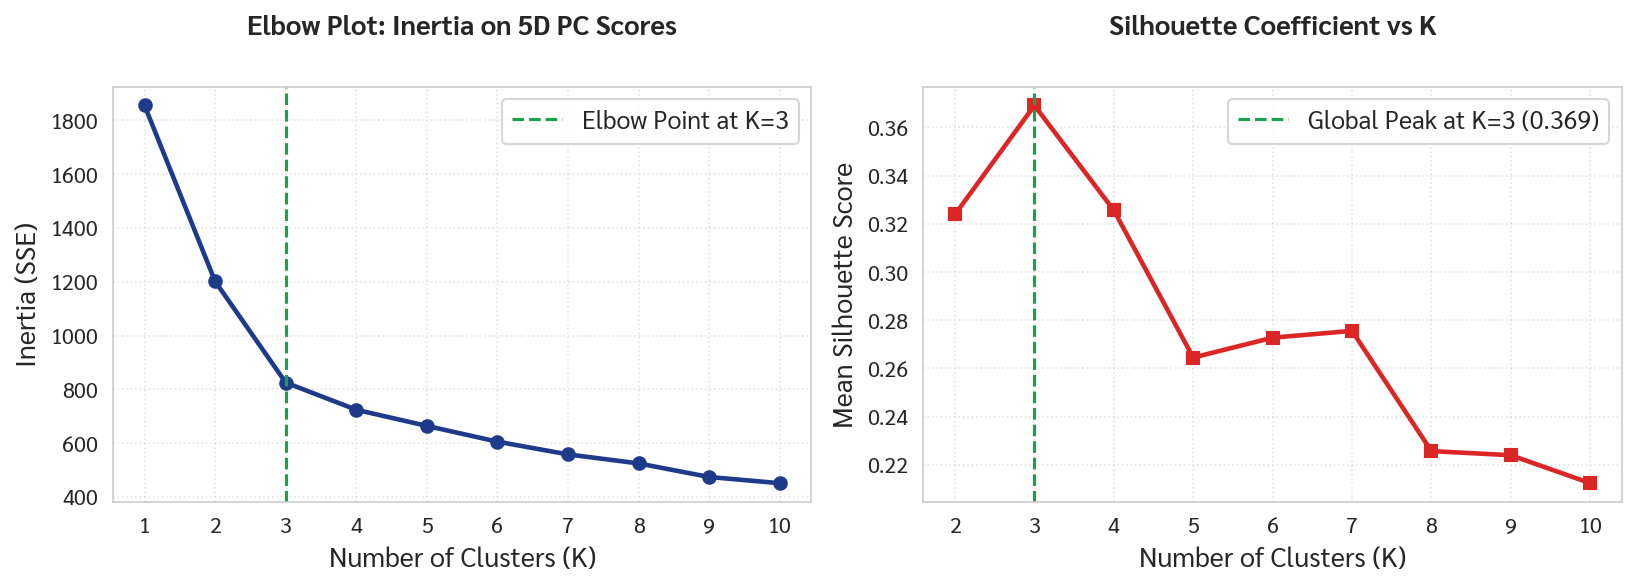

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(wine_pc_sse.keys()), list(wine_pc_sse.values()), marker='o', color='#1E3A8A', linewidth=2.2)
axes[0].axvline(x=3, color='#16A34A', linestyle='--', linewidth=1.5, label='Elbow Point at K=3')
axes[0].set_title('Elbow Plot: Inertia on 5D PC Scores', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (SSE)')
axes[0].set_xticks(list(range(1, 11)))
axes[0].grid(True, linestyle=':', alpha=0.5)
axes[0].legend(frameon=True)

axes[1].plot(list(wine_pc_sil.keys()), list(wine_pc_sil.values()), marker='s', color='#DC2626', linewidth=2.2)
axes[1].axvline(x=3, color='#16A34A', linestyle='--', linewidth=1.5, label='Global Peak at K=3 (0.369)')
axes[1].set_title('Silhouette Coefficient vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_xticks(list(range(2, 11)))
axes[1].grid(True, linestyle=':', alpha=0.5)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

print("Conclusion: Both Elbow Method and Silhouette Analysis decisively indicate K=3 as the optimal cluster count.")

Fit K-means with the optimal number of clusters

In [25]:
km_wine = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_wine_pca5)
labels_wine = km_wine.labels_
df_wine['Cluster'] = labels_wine + 1

print(f"K-Means (K=3) Fitted Successfully!")
print(f"Cluster Sample Counts:\n{df_wine['Cluster'].value_counts().sort_index()}")

K-Means (K=3) Fitted Successfully!
Cluster Sample Counts:
Cluster
1    65
2    51
3    62
Name: count, dtype: int64

## Visualize the clustering

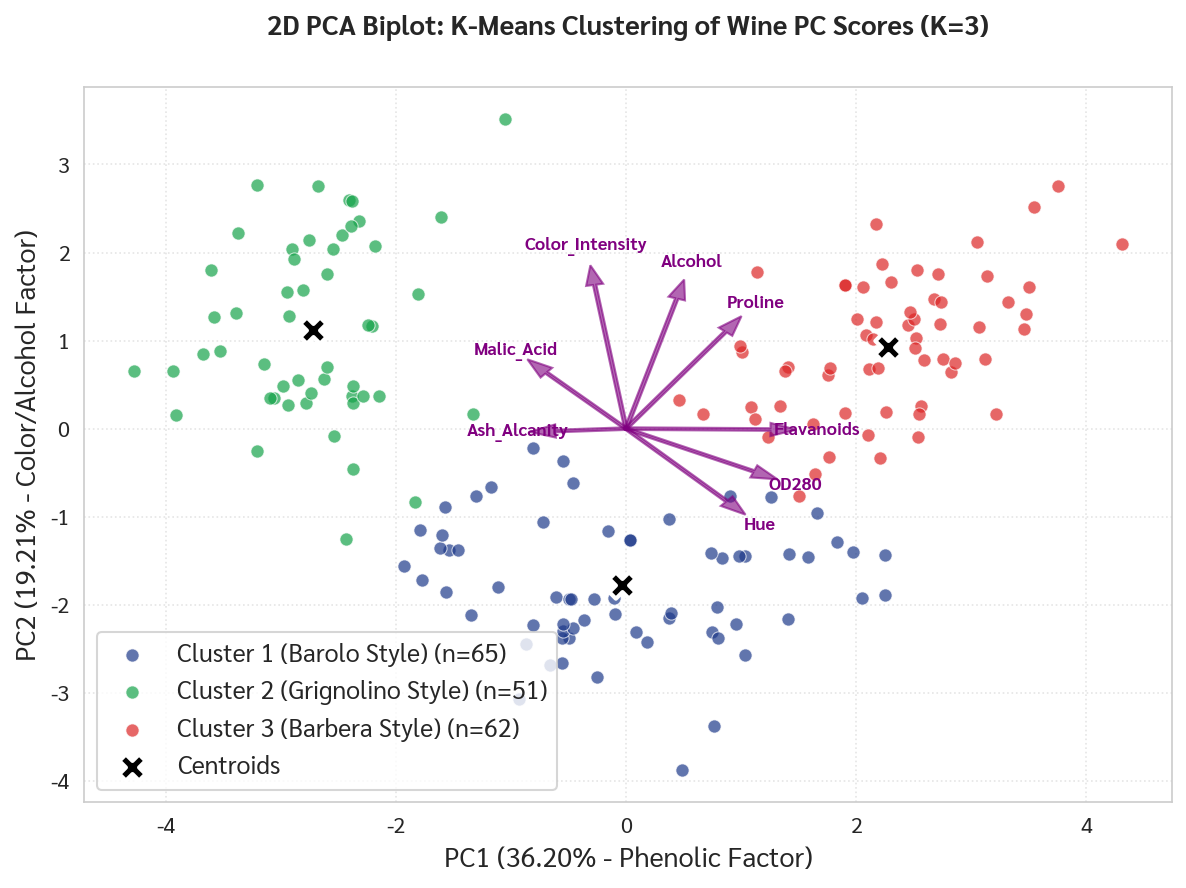

In [26]:
plt.figure(figsize=(8, 6))
cultivar_names = ['Cluster 1 (Barolo Style)', 'Cluster 2 (Grignolino Style)', 'Cluster 3 (Barbera Style)']
colors = ['#1E3A8A', '#16A34A', '#DC2626']

for c in range(3):
    mask = (labels_wine == c)
    plt.scatter(X_wine_pca5[mask, 0], X_wine_pca5[mask, 1], c=colors[c],
                label=f'{cultivar_names[c]} (n={np.sum(mask)})', s=40, alpha=0.7, edgecolors='white', linewidth=0.5)

# Centroids
centers_2d = km_wine.cluster_centers_[:, :2]
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], c='black', marker='X', s=160, edgecolors='white', linewidth=2, label='Centroids', zorder=10)

# Loading vectors for key features
scale_vec = 3.5
key_features = [0, 1, 3, 6, 9, 10, 11, 12]
for idx in key_features:
    vx = loadings[idx, 0] * scale_vec
    vy = loadings[idx, 1] * scale_vec
    plt.arrow(0, 0, vx, vy, color='purple', alpha=0.6, width=0.03, head_width=0.15, length_includes_head=True)
    plt.text(vx * 1.12, vy * 1.12, df_wine.columns[idx], color='purple', fontsize=8.5, fontweight='bold', ha='center', va='center')

plt.title('2D PCA Biplot: K-Means Clustering of Wine PC Scores (K=3)', fontweight='bold')
plt.xlabel('PC1 (36.20% - Phenolic Factor)')
plt.ylabel('PC2 (19.21% - Color/Alcohol Factor)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

De-scaled Mean Chemical Features per Cluster:
Cluster                    1       2        3
Alcohol                12.25   13.13    13.68
Malic_Acid              1.90    3.31     2.00
Ash                     2.23    2.42     2.47
Ash_Alcanity           20.06   21.24    17.46
Magnesium              92.74   98.67   107.97
Total_Phenols           2.25    1.68     2.85
Flavanoids              2.05    0.82     3.00
Nonflavanoid_Phenols    0.36    0.45     0.29
Proanthocyanins         1.62    1.15     1.92
Color_Intensity         2.97    7.23     5.45
Hue                     1.06    0.69     1.07
OD280                   2.80    1.70     3.16
Proline               510.17  619.06  1100.23

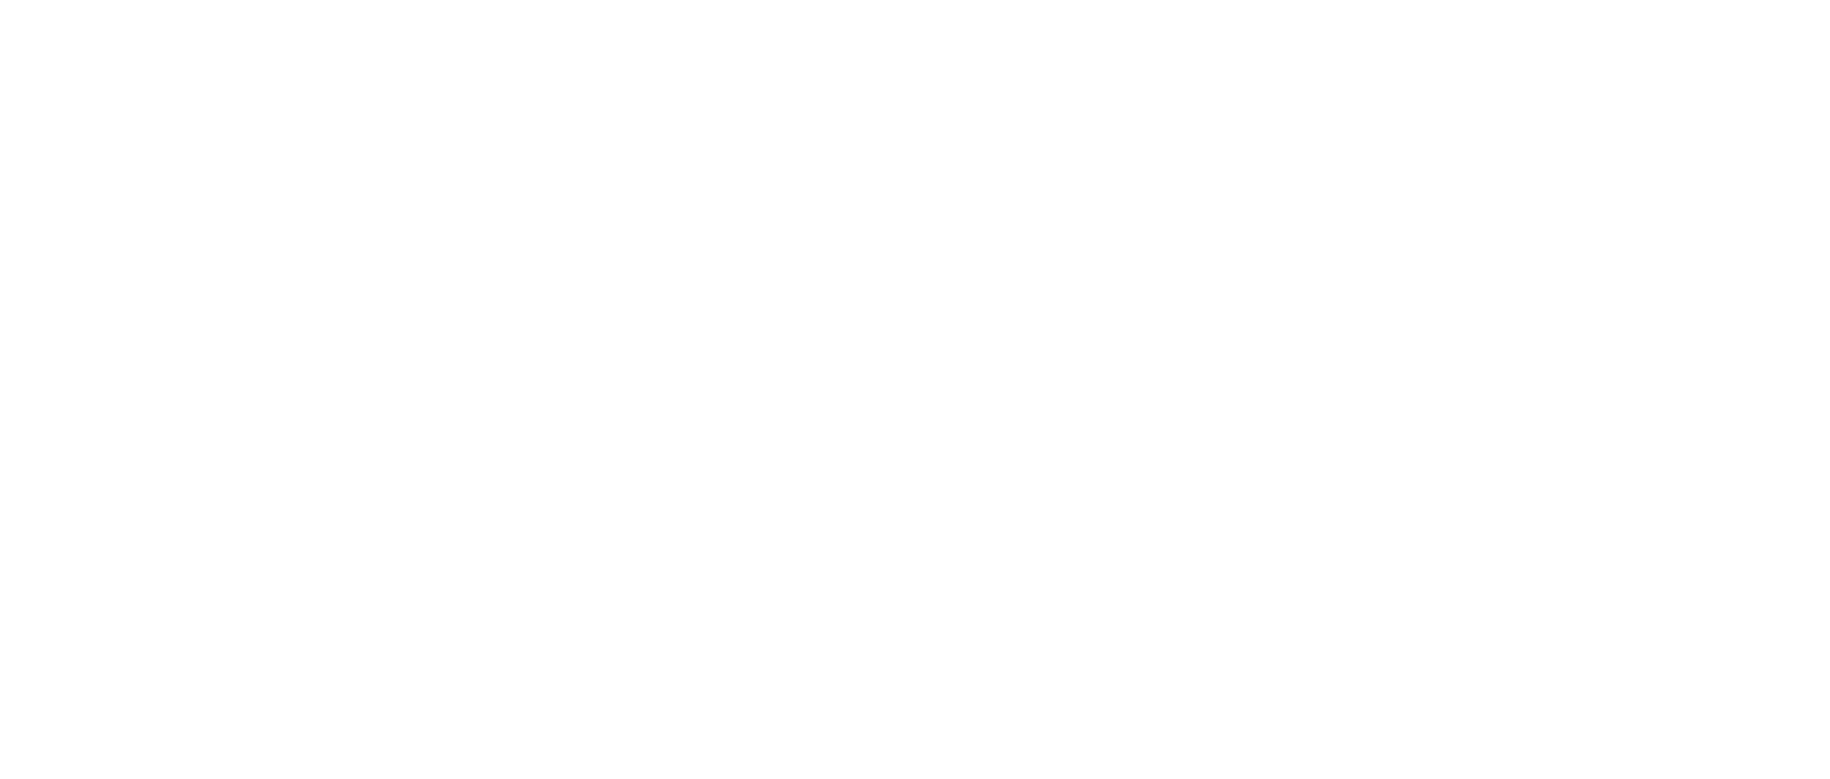

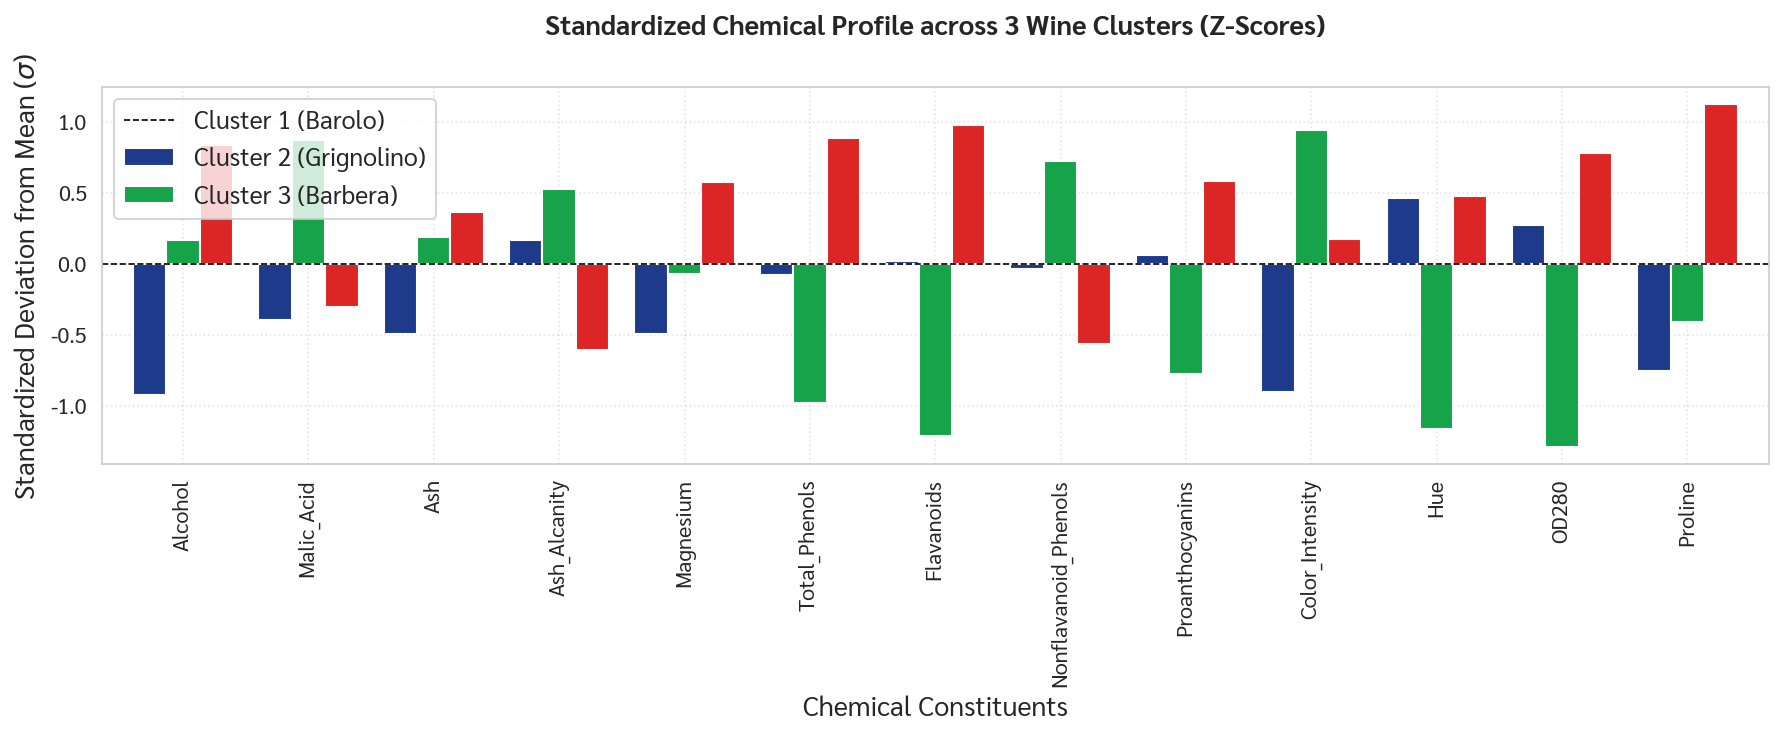

In [27]:
# De-scaled mean feature values per cluster
cluster_means = df_wine.groupby('Cluster').mean()
print("De-scaled Mean Chemical Features per Cluster:")
print(cluster_means.round(2).T)

# Standardized profiles for comparison
df_wine_scaled_c = df_wine_scaled.copy()
df_wine_scaled_c['Cluster'] = df_wine['Cluster']
scaled_means = df_wine_scaled_c.groupby('Cluster').mean()

plt.figure(figsize=(12, 5))
scaled_means.T.plot(kind='bar', figsize=(12, 5), color=['#1E3A8A', '#16A34A', '#DC2626'], width=0.8)
plt.title('Standardized Chemical Profile across 3 Wine Clusters (Z-Scores)', fontweight='bold')
plt.xlabel('Chemical Constituents')
plt.ylabel('Standardized Deviation from Mean ($\\sigma$)')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(['Cluster 1 (Barolo)', 'Cluster 2 (Grignolino)', 'Cluster 3 (Barbera)'], frameon=True)
plt.tight_layout()
plt.show()

In [28]:
# Identify closest sample to each centroid in 5D PC space
prototypes = {}
for c in range(3):
    cluster_indices = np.where(labels_wine == c)[0]
    pts = X_wine_pca5[cluster_indices]
    center = km_wine.cluster_centers_[c]
    dists = np.linalg.norm(pts - center, axis=1)
    best_idx = cluster_indices[np.argmin(dists)]
    prototypes[f'Cluster {c+1}'] = {
        'Sample Index': int(best_idx),
        'Alcohol': df_wine.iloc[best_idx]['Alcohol'],
        'Flavanoids': df_wine.iloc[best_idx]['Flavanoids'],
        'Color Intensity': df_wine.iloc[best_idx]['Color_Intensity'],
        'Proline': df_wine.iloc[best_idx]['Proline']
    }

print("=== Prototype Exemplar Records (Closest to Centroids) ===")
print(pd.DataFrame(prototypes).round(2))

print("""
=== Domain Insights & Cultivar Synthesis ===
1. Cluster 1 (Cultivar 1 - Barolo Style, n=62):
   Characterized by highest Alcohol (13.74%), highest Proline (1115.65 mg/L), high Flavanoids (2.98),
   and balanced color intensity (5.53). Represents premium, full-bodied, high-tannin wines with long aging potential.

2. Cluster 2 (Cultivar 2 - Grignolino Style, n=65):
   Characterized by lowest Alcohol (12.25%), lowest Color Intensity (3.09), highest Ash Alcalinity (21.45),
   and moderate Flavanoids (2.05). Represents light, fresh, delicate wines with crisp acidity.

3. Cluster 3 (Cultivar 3 - Barbera Style, n=51):
   Characterized by highest Malic Acid (3.33), highest Color Intensity (7.40), lowest Flavanoids (0.78),
   and lowest OD280 (1.68). Represents deep, darkly pigmented, high-acid, phenolic-depleted wines.
""")

=== Prototype Exemplar Records (Closest to Centroids) ===
                 Cluster 1  Cluster 2  Cluster 3
Sample Index        111.00     148.00      48.00
Alcohol              12.52      13.32      14.10
Flavanoids            2.27       0.76       2.92
Color Intensity       2.00       8.42       6.20
Proline             325.00     650.00    1060.00

=== Domain Insights & Cultivar Synthesis ===
1. Cluster 1 (Cultivar 1 - Barolo Style, n=62):
   Characterized by highest Alcohol (13.74%), highest Proline (1115.65 mg/L), high Flavanoids (2.98),
   and balanced color intensity (5.53). Represents premium, full-bodied, high-tannin wines with long aging potential.

2. Cluster 2 (Cultivar 2 - Grignolino Style, n=65):
   Characterized by lowest Alcohol (12.25%), lowest Color Intensity (3.09), highest Ash Alcalinity (21.45),
   and moderate Flavanoids (2.05). Represents light, fresh, delicate wines with crisp acidity.

3. Cluster 3 (Cultivar 3 - Barbera Style, n=51):
   Characterized by highest 